In [32]:

import sys
!{sys.executable} -m pip install shap lime

'c:\Users\Remih\OneDrive\Bureau\Master' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [33]:
import pandas as pd

df = pd.read_csv("wine-quality-white-and-red.xls", sep=',')

In [34]:
df.head

<bound method NDFrame.head of        type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0     white            7.0             0.270         0.36            20.7   
1     white            6.3             0.300         0.34             1.6   
2     white            8.1             0.280         0.40             6.9   
3     white            7.2             0.230         0.32             8.5   
4     white            7.2             0.230         0.32             8.5   
...     ...            ...               ...          ...             ...   
6492    red            6.2             0.600         0.08             2.0   
6493    red            5.9             0.550         0.10             2.2   
6494    red            6.3             0.510         0.13             2.3   
6495    red            5.9             0.645         0.12             2.0   
6496    red            6.0             0.310         0.47             3.6   

      chlorides  free sulfur dioxide  total s

In [35]:
df.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='str')

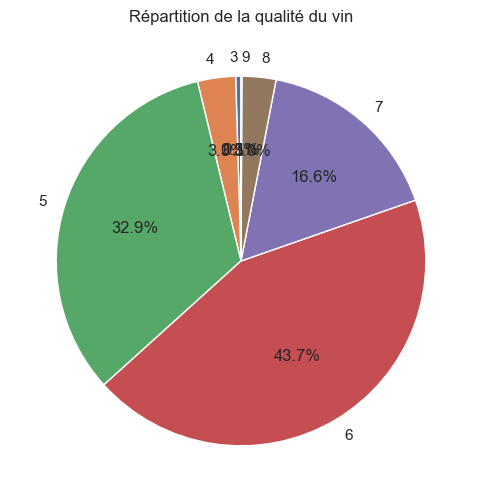

In [36]:
counts = df["quality"].value_counts().sort_index()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition de la qualité du vin")
plt.show()

La répartition de la qualité des vins montre une distribution centrée sur des notes moyennes. En effet, près de 44% des vins obtiennent une note de 6, et environ 33% une note de 5, ce qui représente à eux deux plus des trois quarts de l'ensemble. Les notes extrêmes comme 3, 4, 8 ou 9 sont moins nombreuses. 

In [37]:
counts

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

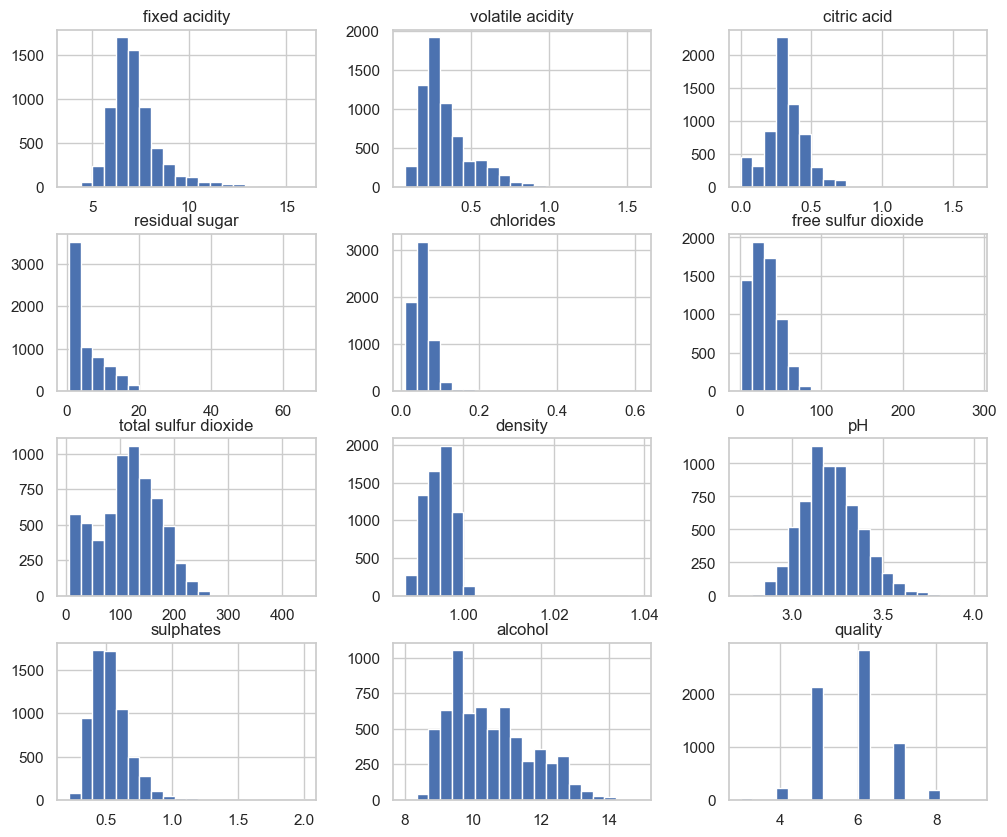

In [38]:
df.hist(figsize=(12,10), bins=20)
plt.show()

La plupart des variables sont concentrées sur de faibles valeurs avec quelques cas extrêmes, à l'exception du pH et de la densité qui sont plus régulièrement répartis. La qualité des vins reste dominée par les notes 5 et 6, ce qui confirme ce qui a été décrit précédemment.

## Analyse Bivariée 

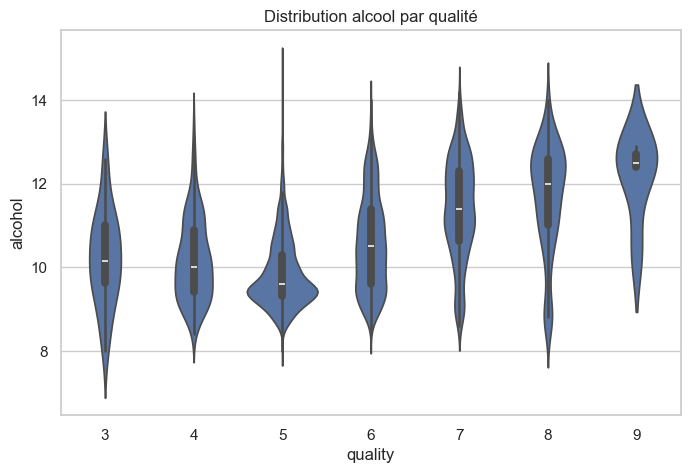

In [39]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.violinplot(x="quality", y="alcohol", data=df)

plt.title("Distribution alcool par qualité")
plt.show()

On observe une certaine tendance: plus la qualité du vin est élevée, plus son taux d'alcool tend à être fort. Les vins notés 5 ont les taux les plus bas, autour de 9-10°. A l'inverse ceux notés 8 ou 9 se concentrent davantage autour de 12-13°. Il semble donc avoir un lien assez fort entre la qualité du vin et le niveau d'alcool.

In [40]:
print(df.dtypes)

type                        str
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


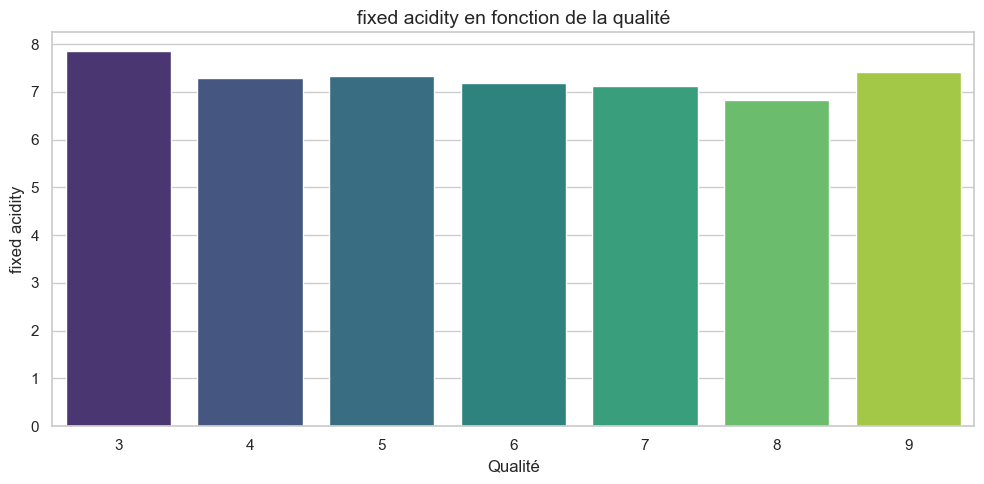

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


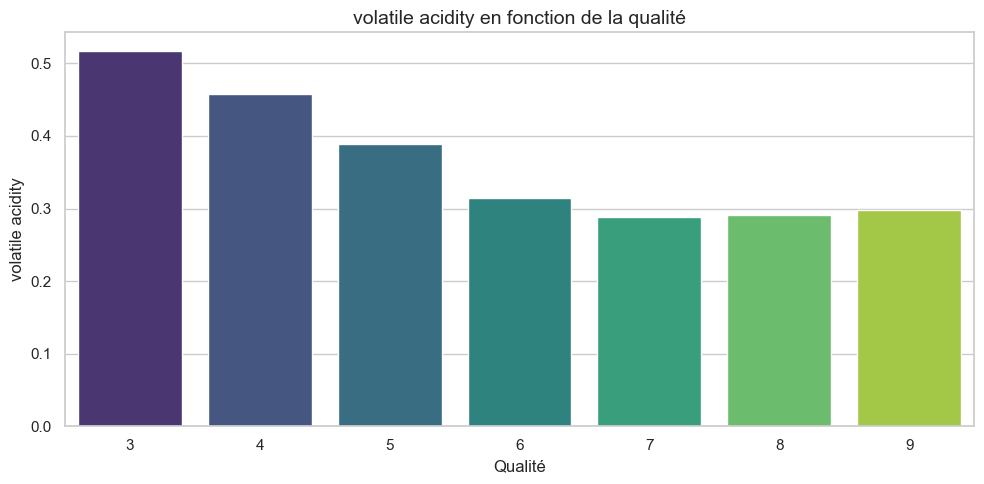

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


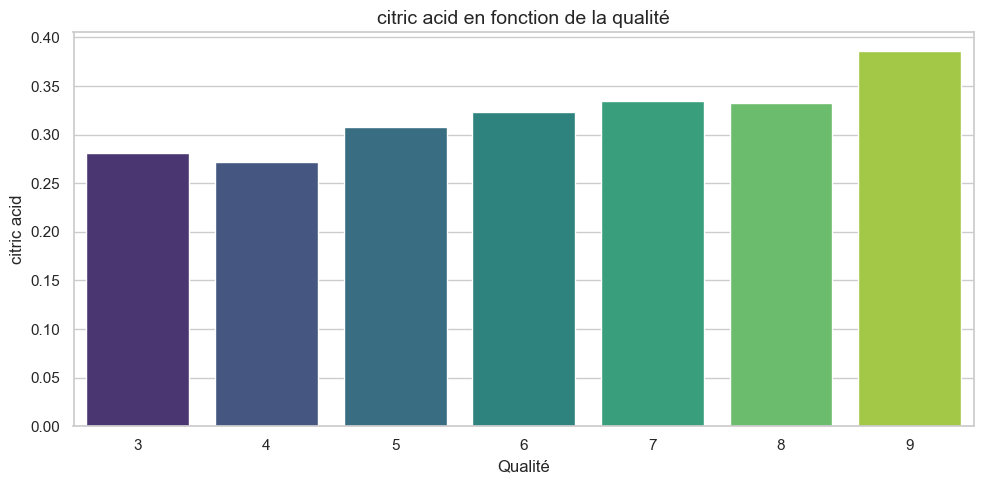

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


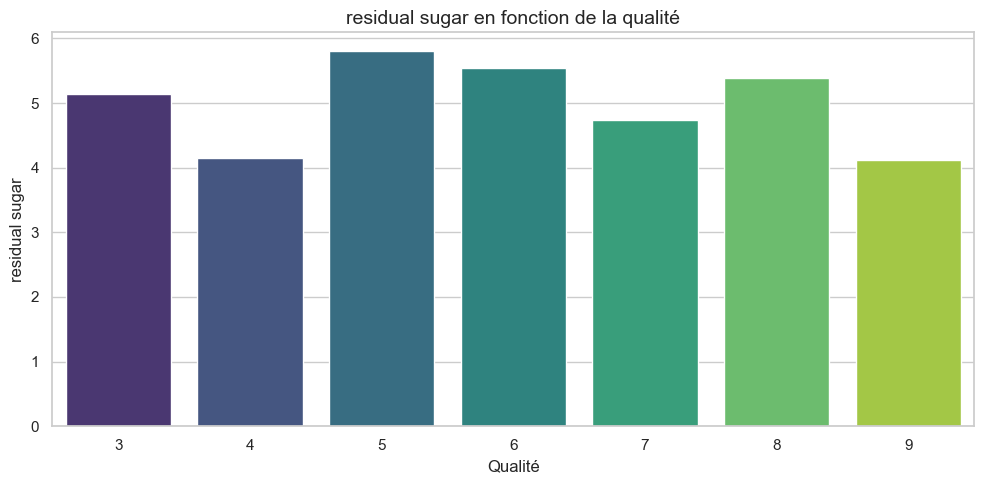

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


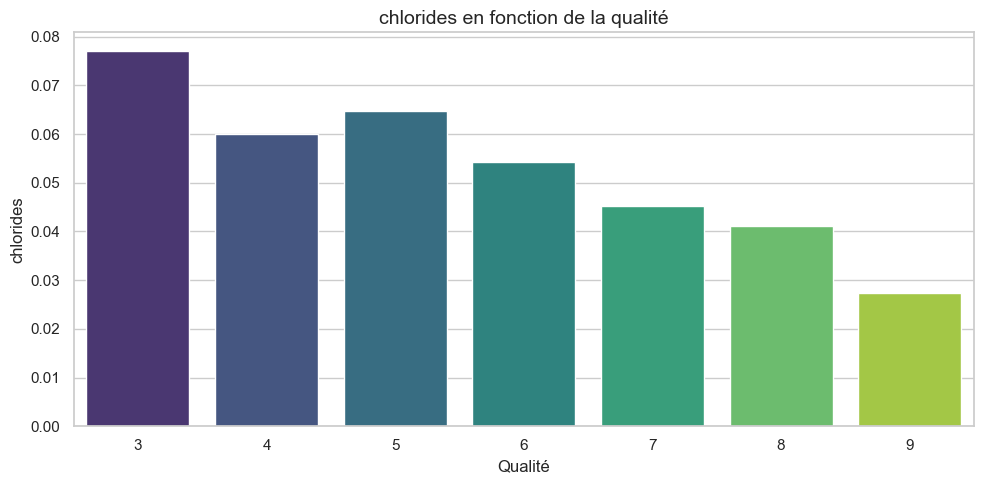

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


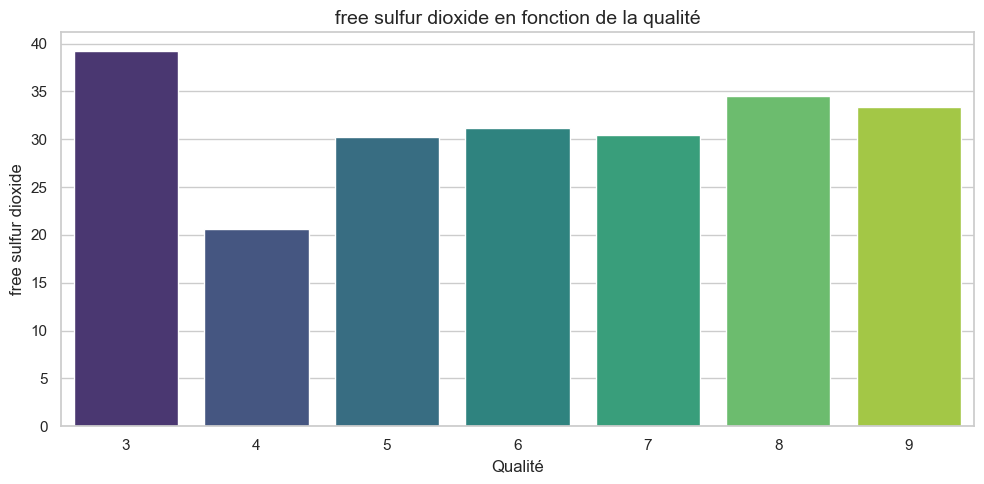

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


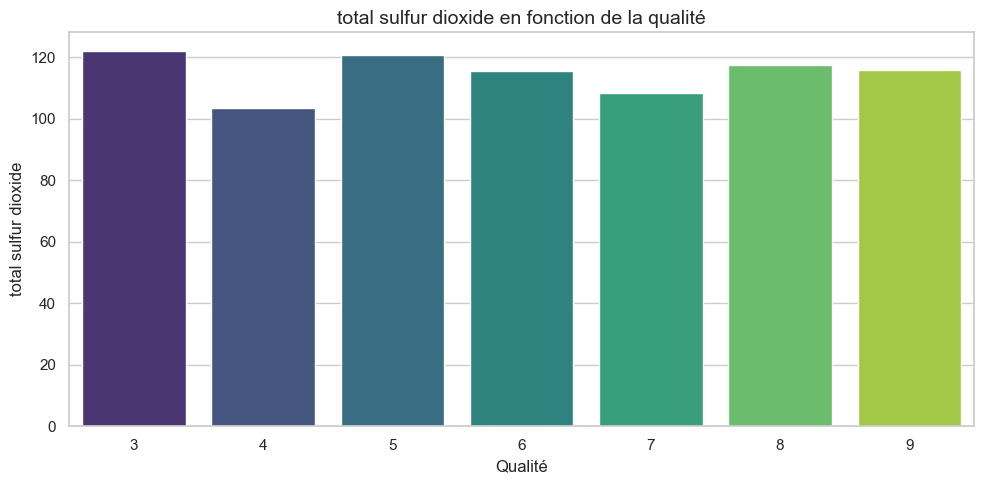

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


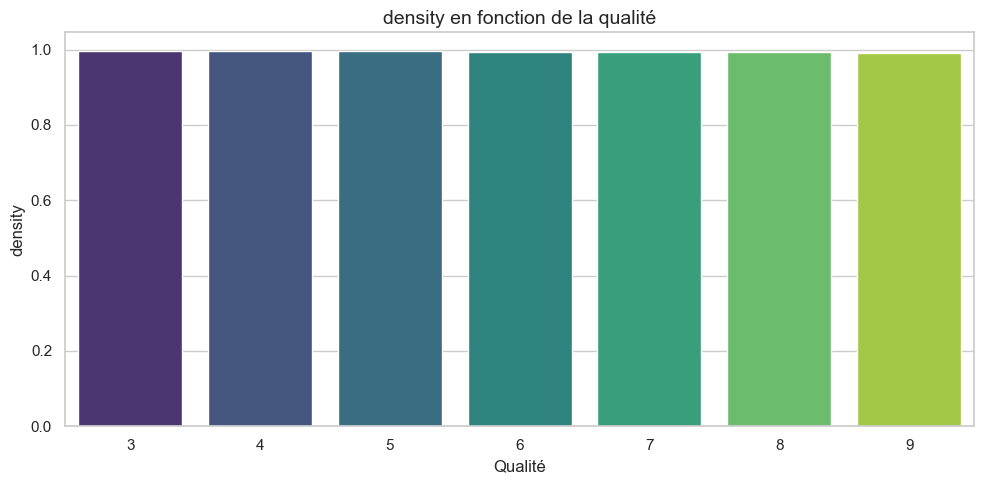

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


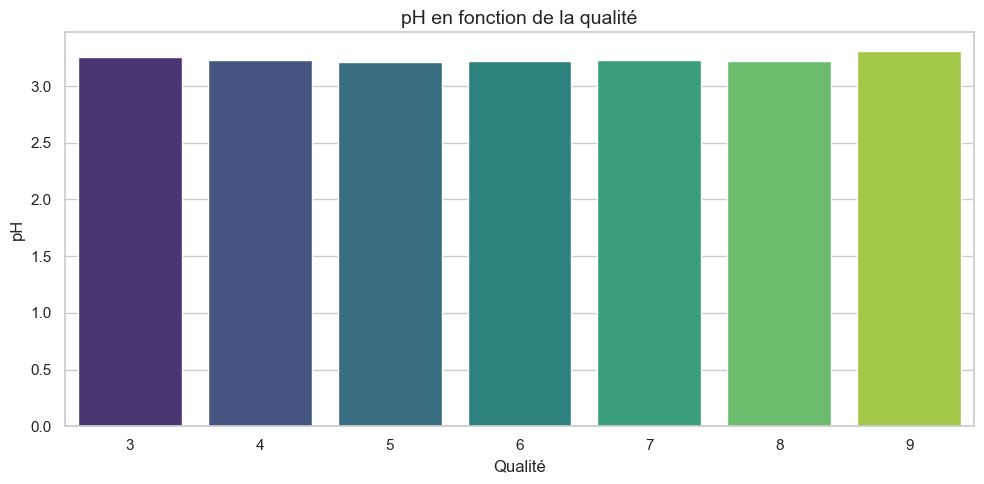

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


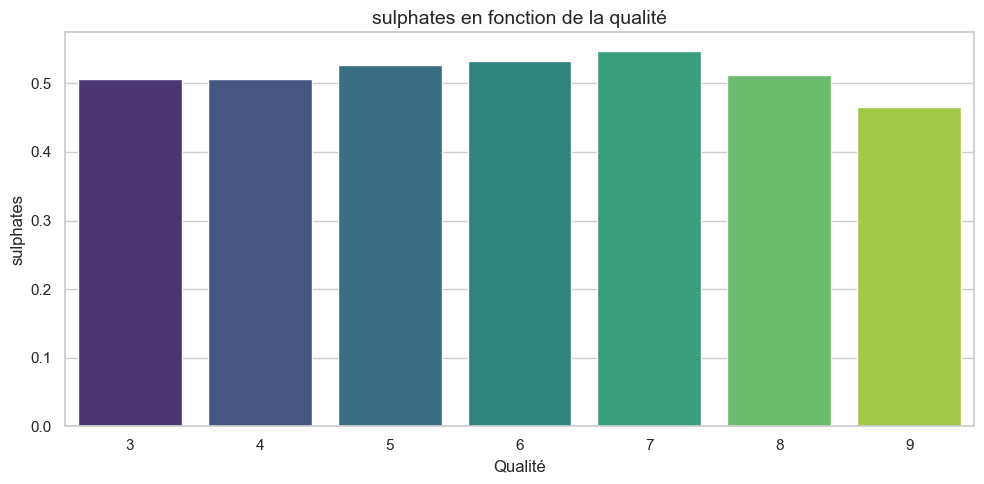

C:\Users\Remih\AppData\Local\Temp\ipykernel_24928\2369482691.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


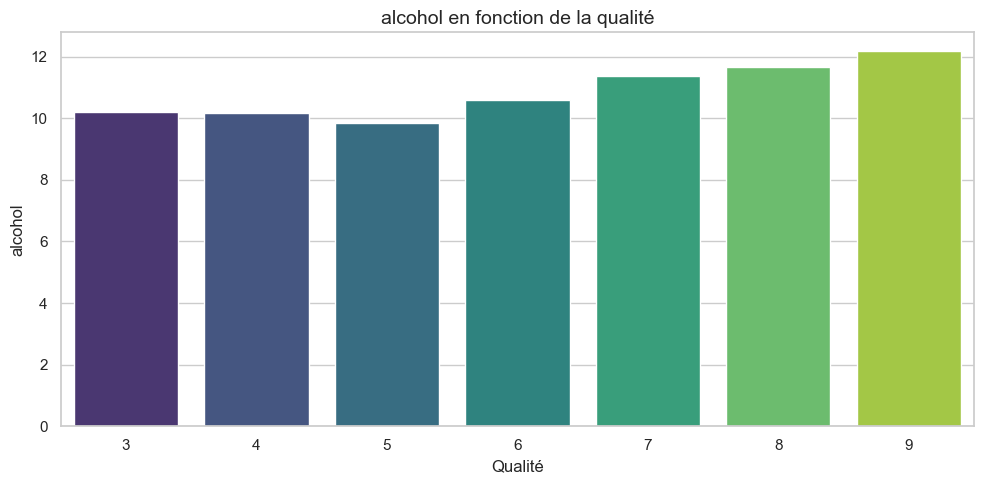

In [41]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

quantitative_columns = df.select_dtypes(include="float64").columns

for column in quantitative_columns:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        x="quality",
        y=column,
        data=df,
        palette="viridis",
        errorbar=None
    )

    plt.title(f"{column} en fonction de la qualité", fontsize=14)
    plt.xlabel("Qualité")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()


Ces graphiques permettent d'étudier les relations des différentes variables avec la variable cible (la qualité du vin). Par exemple, plus la qualité du vin est élevée, moins il contient de chlorures. Les meilleurs vins (note 9) ont donc une teneur en sel nettement plus faible que les vins de mauvaise qualité

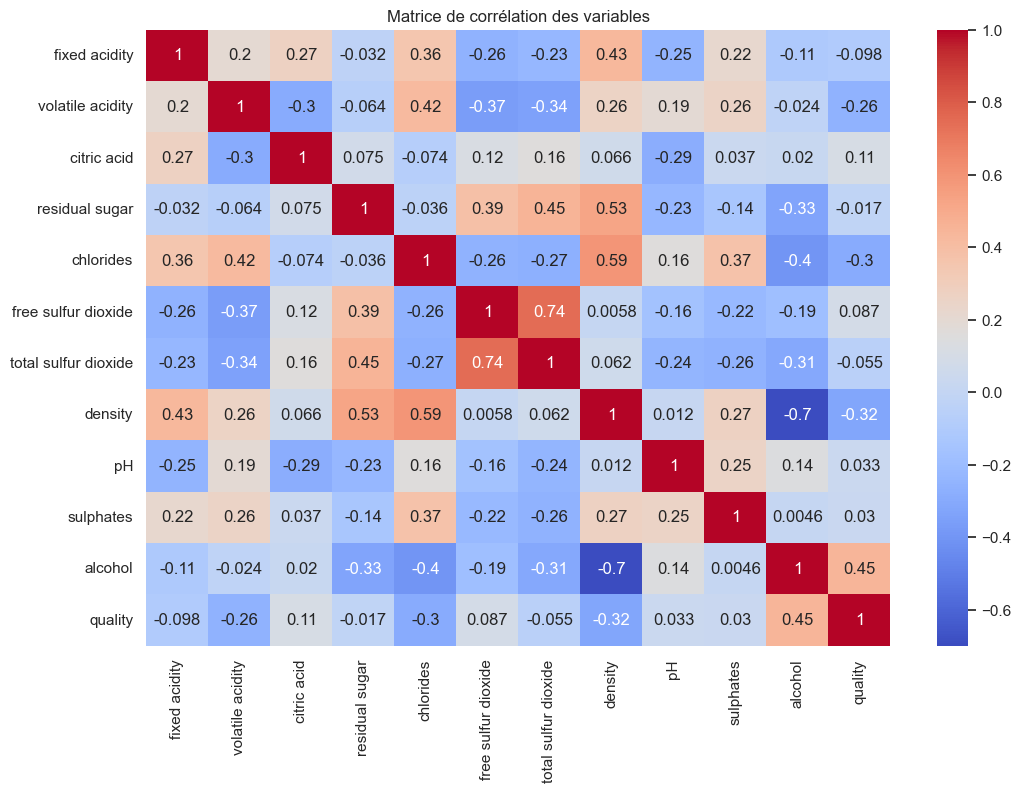

In [42]:

# Sélectionner les colonnes numériques
numerical_columns = df.select_dtypes(include=['float64', 'int']).columns

# Créer un sous-DataFrame avec les colonnes numériques
numerical_data = df[numerical_columns]

# Calculer la matrice de corrélation
correlation_matrix = numerical_data.corr(method='spearman')

# Afficher la matrice
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation des variables')
plt.show()

La corrélation la plus forte est celle entre le dioxyde de soufre libre et son total (0,74), ce qui est logique puisqu'ils mesurent 2 grandeurs fortement liées. On note également que l'alcool est fortement négativement corrélé à la densité (-0,7). Concernant la qualité, c'est l'alcool qui présente la corrélation positive la plus marquée (0,45) ce qui confirme l'observation du graphique précédent. A l'inverse l'acidité volatile est négativement corrélée (-0,26) ce qui suggère que les vins trop acides sont moins bien notés.

In [43]:
#Supprimer car trop corrélé
df = df.drop(['free sulfur dioxide', 'density'], axis=1)

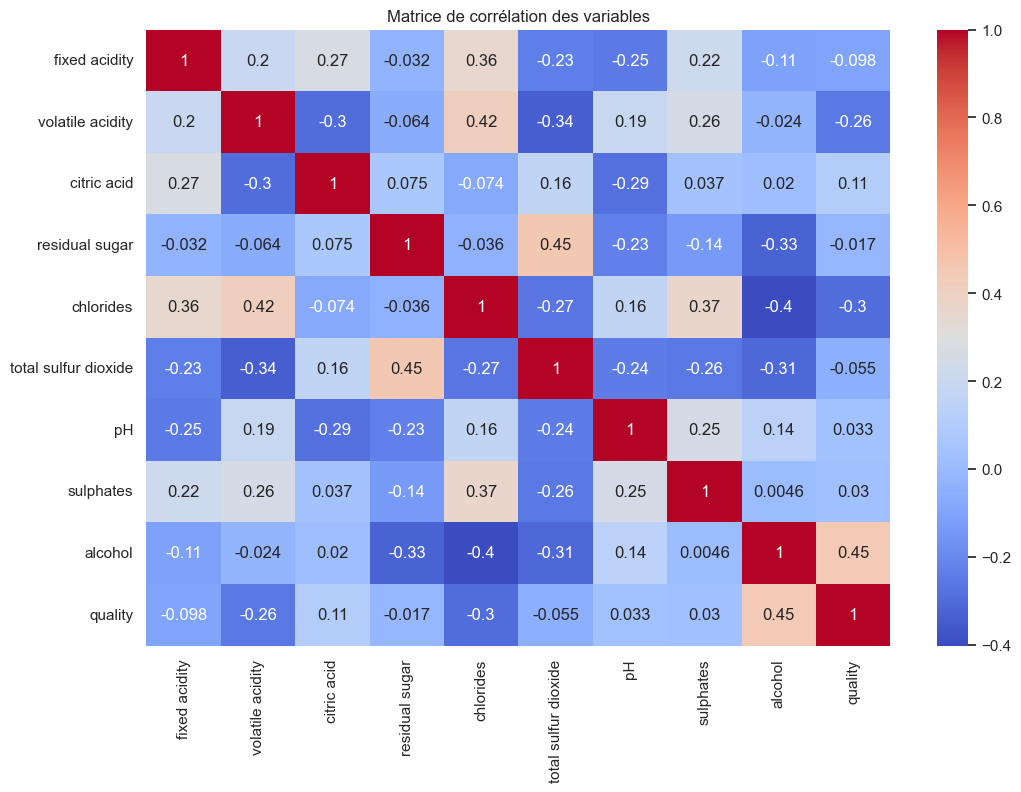

In [44]:
# Sélectionner les colonnes numériques
numerical_columns = df.select_dtypes(include=['float64', 'int']).columns

# Créer un sous-DataFrame avec les colonnes numériques
numerical_data = df[numerical_columns]

# Calculer la matrice de corrélation
correlation_matrix = numerical_data.corr(method='spearman')

# Afficher la matrice
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation des variables')
plt.show()

## Valeurs atypiques

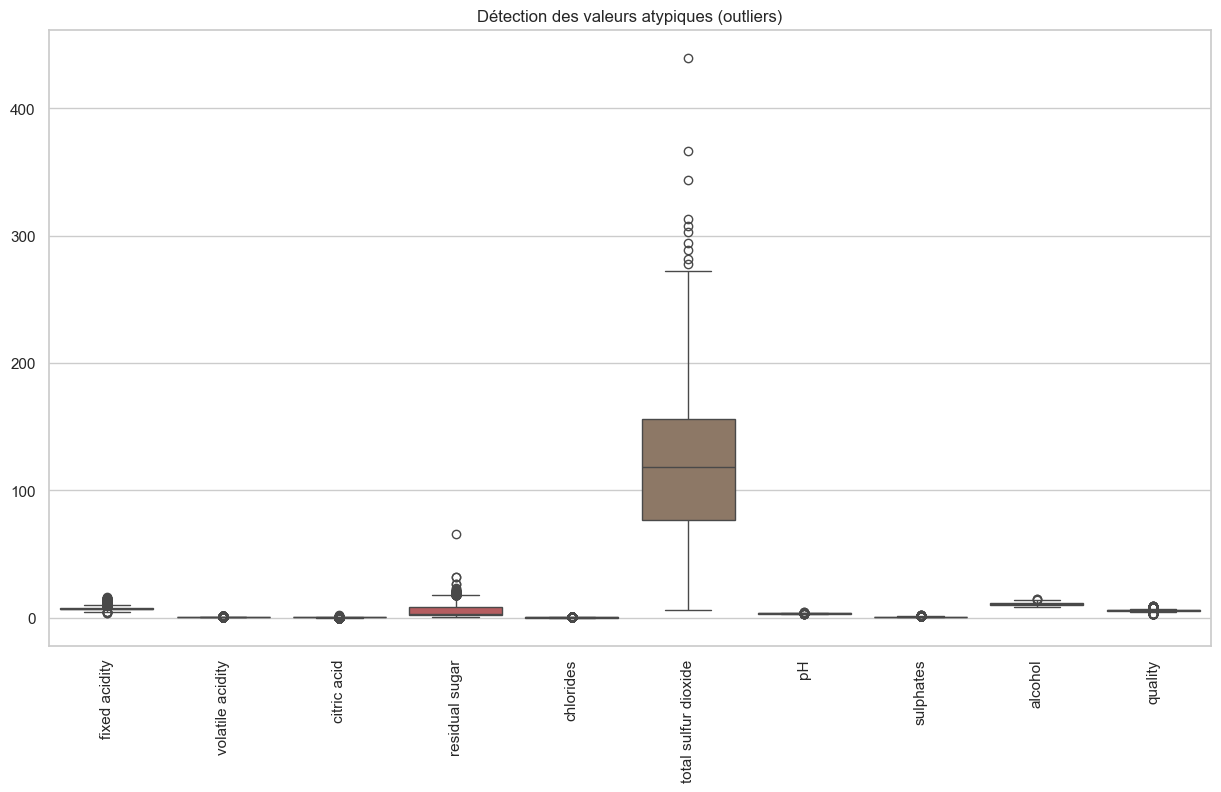

In [45]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.title("Détection des valeurs atypiques (outliers)")
plt.show()

Le dioxyde de soufre total est la variable la plus problématique, avec de nombreux outliers très élevés pouvant dépasser 440. Le sucre résiduel présente également quelques valeurs extrêmes notables. 

In [46]:
Q1 = numerical_data.quantile(0.25)
Q3 = numerical_data.quantile(0.75)
IQR = Q3 - Q1


mask = ~((numerical_data < (Q1 - 1.5 * IQR)) | (numerical_data > (Q3 + 1.5 * IQR))).any(axis=1)


df_clean = df[mask]

print(f"Avant : {df.shape[0]} lignes")
print(f"Après : {df_clean.shape[0]} lignes")
print(f"Supprimées : {df.shape[0] - df_clean.shape[0]} lignes")

Avant : 6497 lignes
Après : 4886 lignes
Supprimées : 1611 lignes


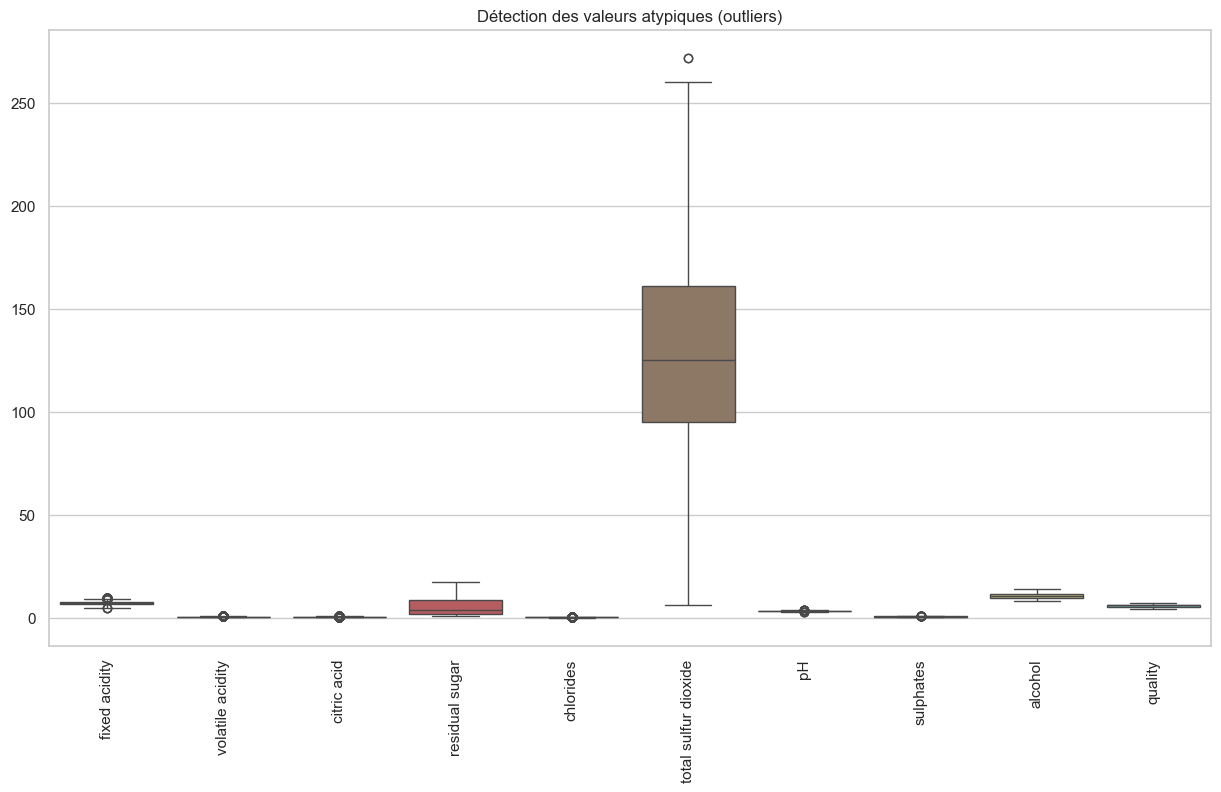

In [47]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_clean)

plt.xticks(rotation=90)
plt.title("Détection des valeurs atypiques (outliers)")
plt.show()

## Vérification des NA

In [48]:
df_clean.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
total sulfur dioxide    0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [49]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4886 entries, 1 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  4886 non-null   str    
 1   fixed acidity         4886 non-null   float64
 2   volatile acidity      4886 non-null   float64
 3   citric acid           4886 non-null   float64
 4   residual sugar        4886 non-null   float64
 5   chlorides             4886 non-null   float64
 6   total sulfur dioxide  4886 non-null   float64
 7   pH                    4886 non-null   float64
 8   sulphates             4886 non-null   float64
 9   alcohol               4886 non-null   float64
 10  quality               4886 non-null   int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 458.1 KB


In [50]:
#transformer type et quality en catégorie

df_clean['type'] = df_clean['type'].astype('category')
df_clean['quality'] = df_clean['quality'].astype('category')


In [51]:
df_clean2 = df_clean

In [52]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4886 entries, 1 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   type                  4886 non-null   category
 1   fixed acidity         4886 non-null   float64 
 2   volatile acidity      4886 non-null   float64 
 3   citric acid           4886 non-null   float64 
 4   residual sugar        4886 non-null   float64 
 5   chlorides             4886 non-null   float64 
 6   total sulfur dioxide  4886 non-null   float64 
 7   pH                    4886 non-null   float64 
 8   sulphates             4886 non-null   float64 
 9   alcohol               4886 non-null   float64 
 10  quality               4886 non-null   category
dtypes: category(2), float64(9)
memory usage: 391.3 KB


##  Encode de la variable Y (Qualité)

In [54]:

# 1 = white, 0 = red
df_clean['type'] = (df_clean['type'] == 'white').astype(int)

In [55]:
df_clean

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,quality
1,1,6.3,0.300,0.34,1.6,0.049,132.0,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,97.0,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,186.0,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,186.0,3.19,0.40,9.9,6
5,1,8.1,0.280,0.40,6.9,0.050,97.0,3.26,0.44,10.1,6
...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,44.0,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,51.0,3.52,0.76,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,40.0,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,44.0,3.57,0.71,10.2,5


# Variable cible en catégorie

on voit que la distribution est tres déséquilibré c'est pour ca qu'on va regrouper par classe 

In [56]:
def regrouper_quality(q):
    if q <= 4:
        return 0  # Mauvaise qualité
    elif q <= 6:
        return 1  # Qualité moyenne
    else:
        return 2  # Bonne qualité

df_clean['quality_grouped'] = df_clean['quality'].map(regrouper_quality)

print(df_clean['quality_grouped'].value_counts(normalize=True))

quality_grouped
1    0.781621
2    0.189930
0    0.028449
Name: proportion, dtype: float64


In [57]:
df_clean = df_clean.drop(columns=['quality'])

In [58]:
# Séparer les features et la target
from sklearn.model_selection import train_test_split


X = df_clean.drop('quality_grouped', axis=1)
y = df_clean['quality_grouped']

# Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [59]:
#Standardisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Modèles

In [60]:
# Modèle 1: Régression Logistique (Classification)
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Évaluation des modèles
print("### Régression Logistique ###")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))

### Régression Logistique ###
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.81      0.95      0.87       769
           2       0.47      0.18      0.26       182

    accuracy                           0.78       978
   macro avg       0.43      0.38      0.38       978
weighted avg       0.72      0.78      0.74       978

Accuracy: 0.7832310838445807


c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [61]:
# Linear SVM
from sklearn.calibration import LinearSVC


l_SVC = LinearSVC(random_state=42, max_iter=2000)
l_SVC.fit(X_train_scaled, y_train)
y_pred_lsvc = l_SVC.predict(X_test_scaled)
print("### Linear SVM ###")
print(classification_report(y_test, y_pred_lsvc))
print("Accuracy:", accuracy_score(y_test, y_pred_lsvc))

### Linear SVM ###
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.80      0.98      0.88       769
           2       0.62      0.13      0.22       182

    accuracy                           0.80       978
   macro avg       0.47      0.37      0.37       978
weighted avg       0.75      0.80      0.73       978

Accuracy: 0.7955010224948875


c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [62]:
# SVM Kernel Linéaire
from sklearn.svm import SVC


svc = SVC(kernel='linear', random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
print("### SVM Kernel Linéaire ###")
print(classification_report(y_test, y_pred_svc))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

### SVM Kernel Linéaire ###
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.79      1.00      0.88       769
           2       0.00      0.00      0.00       182

    accuracy                           0.79       978
   macro avg       0.26      0.33      0.29       978
weighted avg       0.62      0.79      0.69       978

Accuracy: 0.7862985685071575


c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

# Variable cible en binaire 

On a pas réussi à prédire la classe 0, on passe donc à la transformation de notre variable cible en binaire avec 0 : mauvaise qualité et 1 bonne qualité

In [63]:
df_clean2['quality_binaire'] = df_clean2['quality_grouped'].apply(
    lambda x: 0 if x in [0, 2] else 1
)
    

In [64]:
#Supprimer les variables inutiles
df_clean2 = df_clean2.drop(columns=['quality_grouped', 'quality'])

In [65]:
# Séparer les features et la target
from sklearn.model_selection import train_test_split


X_bis = df_clean2.drop('quality_binaire', axis=1)
y_bis = df_clean2['quality_binaire']

# Diviser les données en ensemble d'entraînement et de test
X_train_bis, X_test_bis, y_train_bis, y_test_bis = train_test_split(X_bis, y_bis, test_size=0.2, random_state=42)

In [66]:
#Standardisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled_bis = scaler.fit_transform(X_train_bis)
X_test_scaled_bis = scaler.transform(X_test_bis)


In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled_bis, y_train_bis)
y_pred_rf_bis = rf.predict(X_test_scaled_bis)

print("### Random Forest ###")
print(classification_report(y_test_bis, y_pred_rf_bis))
print("Accuracy:", accuracy_score(y_test_bis, y_pred_rf_bis))

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled_bis, y_train_bis)
y_pred_log_bis = log_reg.predict(X_test_scaled_bis)

print("\n### Régression Logistique ###")
print(classification_report(y_test_bis, y_pred_log_bis))
print("Accuracy:", accuracy_score(y_test_bis, y_pred_log_bis))

# SVM RBF
svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svm_rbf.fit(X_train_scaled_bis, y_train_bis)
y_pred_rbf = svm_rbf.predict(X_test_scaled_bis)

print("\n### SVM Kernel RBF ###")
print(classification_report(y_test_bis, y_pred_rbf))
print("Accuracy:", accuracy_score(y_test_bis, y_pred_rbf))

### Random Forest ###
              precision    recall  f1-score   support

           0       0.79      0.53      0.63       209
           1       0.88      0.96      0.92       769

    accuracy                           0.87       978
   macro avg       0.83      0.74      0.78       978
weighted avg       0.86      0.87      0.86       978

Accuracy: 0.8680981595092024

### Régression Logistique ###
              precision    recall  f1-score   support

           0       0.53      0.15      0.23       209
           1       0.81      0.96      0.88       769

    accuracy                           0.79       978
   macro avg       0.67      0.56      0.56       978
weighted avg       0.75      0.79      0.74       978

Accuracy: 0.7903885480572597

### SVM Kernel RBF ###
              precision    recall  f1-score   support

           0       0.67      0.16      0.26       209
           1       0.81      0.98      0.89       769

    accuracy                           0.80    

Avec une accuracy de 87%, le Random Forest est meilleur la régression logistique (79%) et gère  mieux les vins de mauvaise qualité. La régression logistique a plus de mal à classer les vins de mauvaise qualité . Le Random Forest est donc le choix le plus adapté par rapport à la régression logistique et le SVM kernel.

# Tuning

In [68]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform

# Tuning Random Forest 
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_scaled_bis, y_train_bis)
best_rf = grid_rf.best_estimator_

print("Meilleurs paramètres RF :", grid_rf.best_params_)
print("Accuracy CV             :", round(grid_rf.best_score_, 4))

# Tuning Regression Logistic
param_grid_lr = {
    'C':       [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train_scaled_bis, y_train_bis)
best_lr = grid_lr.best_estimator_

print("\nMeilleurs paramètres LR :", grid_lr.best_params_)
print("Accuracy CV             :", round(grid_lr.best_score_, 4))

#  Tuning SVM 
param_dist_svm = {
    'C':     loguniform(0.1, 100),
    'gamma': loguniform(1e-4, 1),
}

rand_svm = RandomizedSearchCV(
    SVC(kernel='rbf', random_state=42, probability=True),
    param_dist_svm,
    n_iter=10, cv=3, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
rand_svm.fit(X_train_scaled_bis, y_train_bis)
best_svm = rand_svm.best_estimator_

print("\nMeilleurs paramètres SVM :", rand_svm.best_params_)
print("Accuracy CV              :", round(rand_svm.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres RF : {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
Accuracy CV             : 0.8401
Fitting 3 folds for each of 6 candidates, totalling 18 fits


c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Meilleurs paramètres LR : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy CV             : 0.7899
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Meilleurs paramètres SVM : {'C': np.float64(1.3292918943162166), 'gamma': np.float64(0.6351221010640696)}
Accuracy CV              : 0.825


En tunant nos modèles, le random forest reste le meilleur des 3 modèles. Pour optimiser les trois modèles, un GridSearchCV a été utilisé pour le Random Forest et la Régression Logistique tandis qu'un RandomizedSearchCV a été appliqué au SVM, cela permet de trouver automatiquement les meilleurs paramètres pour chacun.

# Comparaison des modèles tunés

             Modèle  Accuracy  F1-macro  ROC-AUC
      Random Forest    0.8671    0.7718   0.8678
            SVM RBF    0.8497    0.7413   0.8022
Logistic Regression    0.7904    0.5554   0.6957


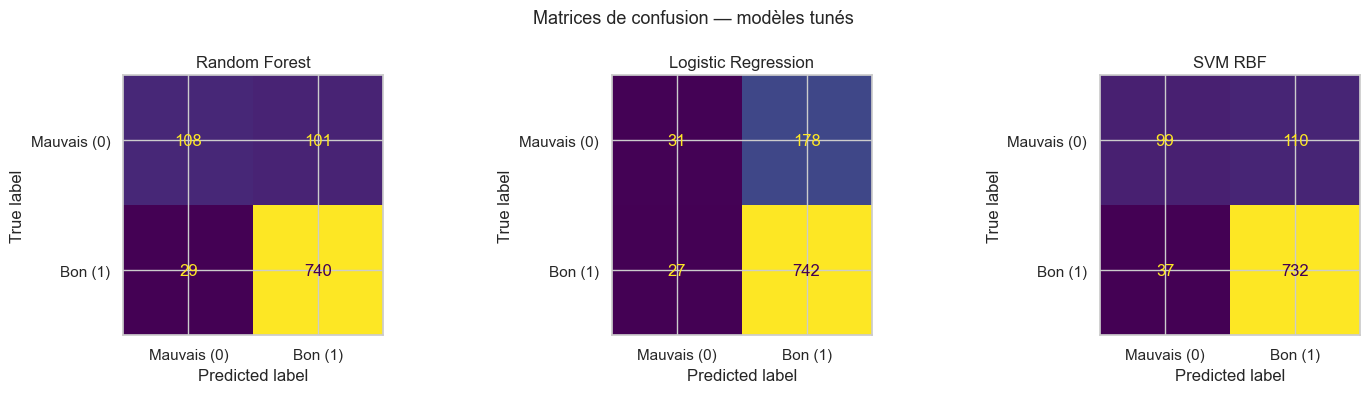

In [69]:
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Random Forest':      best_rf,
    'Logistic Regression': best_lr,
    'SVM RBF':            best_svm
}

#  Tableau récapitulatif 
results = []
for name, model in models.items():
    y_pred  = model.predict(X_test_scaled_bis)
    y_proba = model.predict_proba(X_test_scaled_bis)[:, 1]
    report  = classification_report(y_test_bis, y_pred, output_dict=True)
    results.append({
        'Modèle':   name,
        'Accuracy': round(accuracy_score(y_test_bis, y_pred), 4),
        'F1-macro': round(report['macro avg']['f1-score'], 4),
        'ROC-AUC':  round(roc_auc_score(y_test_bis, y_proba), 4)
    })

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(df_results.to_string(index=False))

#  Matrices de confusion côte à côte 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled_bis)
    ConfusionMatrixDisplay.from_predictions(
        y_test_bis, y_pred,
        display_labels=['Mauvais (0)', 'Bon (1)'],
        colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.suptitle("Matrices de confusion — modèles tunés", fontsize=13)
plt.tight_layout()
plt.show()

Notre meilleur modèle est donc bien le random forest c'est donc celui que l'on va utiliser pour la suite des interprétations, à la fois pour l'interprétabilité globale et l'interprétabilité locale. 

# Interprétabilité Globale

## Permutation Importance

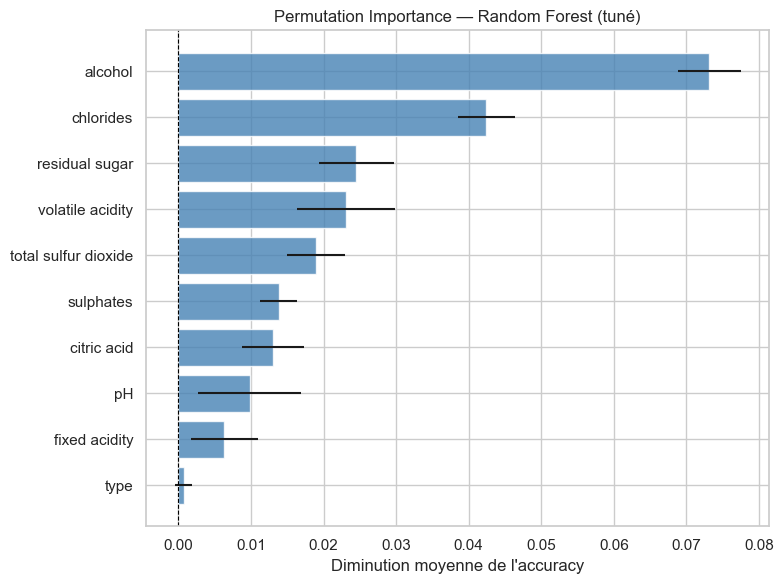

In [70]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_rf, X_test_scaled_bis, y_test_bis,
    n_repeats=10, random_state=42, n_jobs=-1
)
sorted_idx = perm_imp.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    X_bis.columns[sorted_idx],
    perm_imp.importances_mean[sorted_idx],
    xerr=perm_imp.importances_std[sorted_idx],
    color='steelblue', alpha=0.8
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Permutation Importance — Random Forest (tuné)")
ax.set_xlabel("Diminution moyenne de l'accuracy")
plt.tight_layout()
plt.show()

L'alcool et l'acidité volatile sont les 2 variables qui impactent le plus la qualité du vin dans notre modèle.

## PDP

Top 2 variables : ['chlorides', 'alcohol']


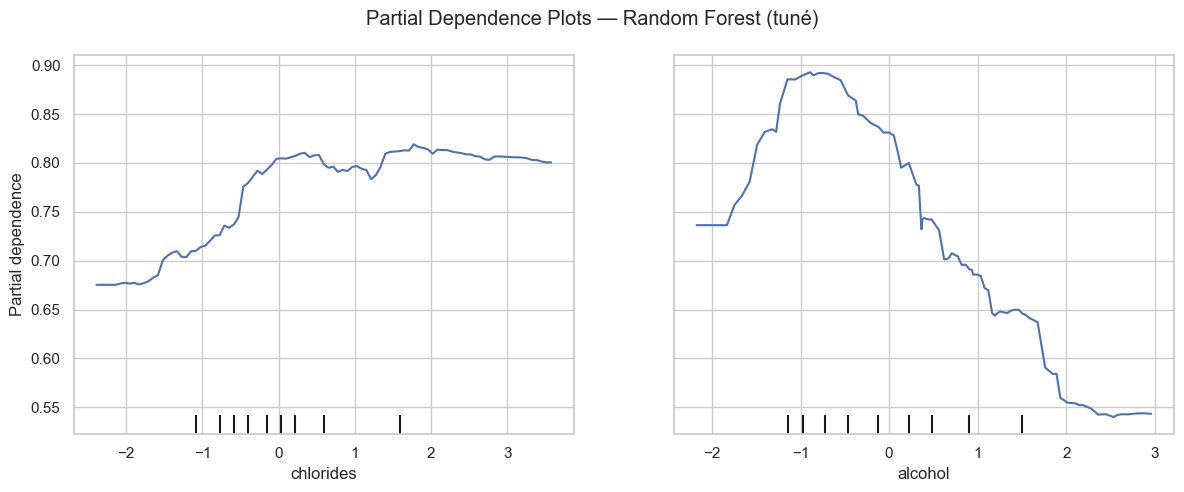

In [71]:
from sklearn.inspection import PartialDependenceDisplay

#On réalise un PDP avec nos 2 variables les plus importantes 
top2 = list(X_bis.columns[perm_imp.importances_mean.argsort()[-2:]])
print("Top 2 variables :", top2)

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train_scaled_bis,               
    features=top2,
    feature_names=list(X_bis.columns), 
    ax=ax
)
plt.suptitle("Partial Dependence Plots — Random Forest (tuné)")
plt.tight_layout()
plt.show()

Concernant le PDP : **L'acidité volatile** a un effet négatif monotone et régulier : plus elle est élevée, plus la probabilité d'un vin de bonne qualité chute (~0.77 à ~0.50), ce qui est cohérent avec son caractère défectueux. **L'alcool** suit quant à lui une relation plutôt sigmoïde : l'effet est quasi nul en dessous de la moyenne, puis monte très fortement entre 0 et +1 avant de saturer à ~0.85. 

## ICE

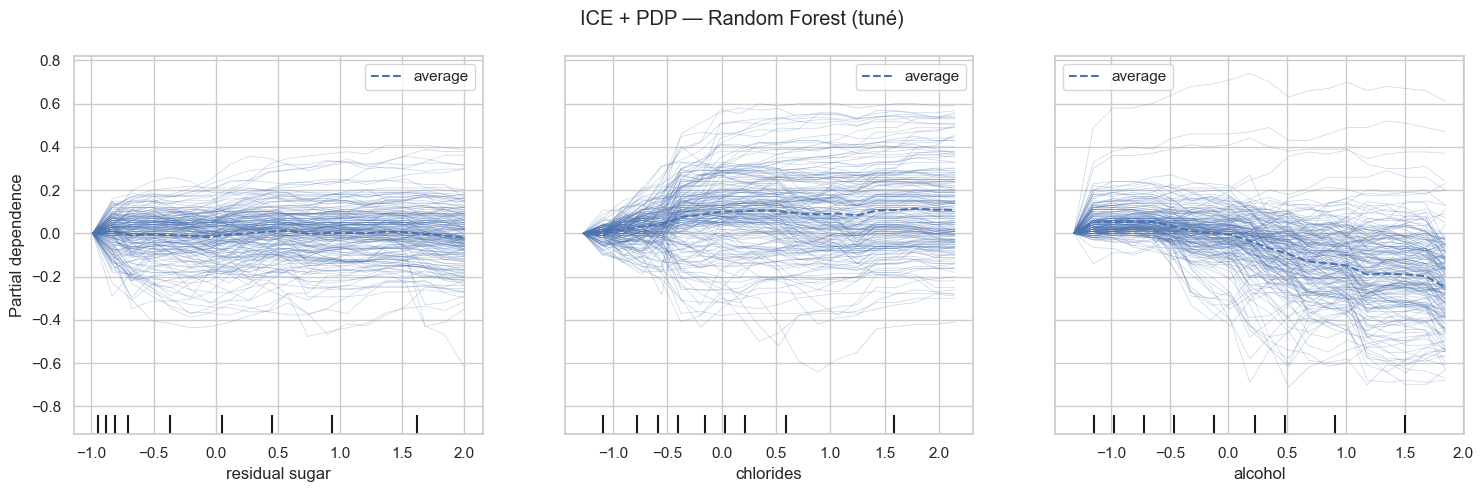

In [72]:
#On test la méthode ICE avec les 3 variables les plus importantes de notre RF
top3 = list(X_bis.columns[perm_imp.importances_mean.argsort()[-3:]])

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train_scaled_bis,                
    features=top3,
    feature_names=list(X_bis.columns),
    kind='both',
    ax=ax,
    grid_resolution=20,
    n_cols=3,
    subsample=0.05,
    centered=True,
    random_state=42
)
plt.suptitle("ICE + PDP — Random Forest (tuné)")
plt.tight_layout()
plt.show()

Pour **volatile acidity** et **alcohol**, les courbes individuelles suivent globalement la même direction que la moyenne, ce qui confirme des effets cohérents sur l'ensemble des vins, même si l'amplitude varie selon les observations. En revanche, **total sulfur dioxide** présente des courbes très dispersées et des directions opposées autour d'une moyenne quasi nulle, signe que son effet est **fortement hétérogène** et dépend d'interactions avec d'autres variables.

## SHAP (Beeswarm)

In [76]:
import shap
from IPython.display import HTML

# Reconvertir en DataFrame
X_train_df = pd.DataFrame(X_train_scaled_bis, columns=X_bis.columns)
X_test_df  = pd.DataFrame(X_test_scaled_bis,  columns=X_bis.columns)

explainer_shap = shap.TreeExplainer(best_rf)

c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


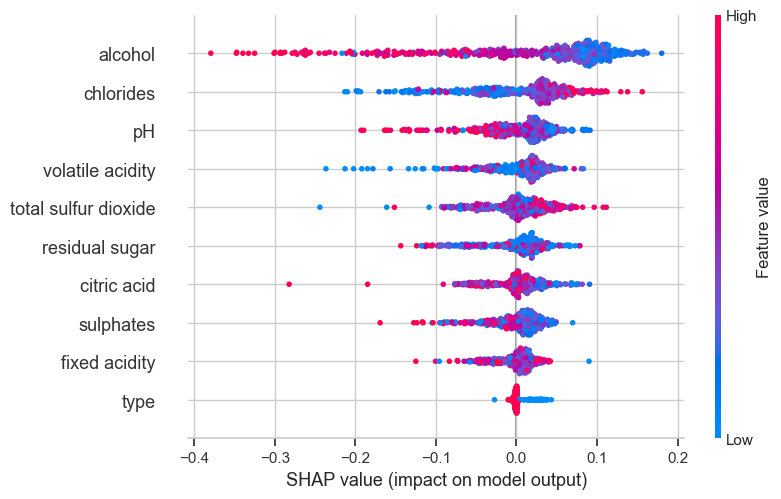

In [77]:
shap_values_train = explainer_shap(X_train_df.iloc[:500])
shap.plots.beeswarm(shap_values_train[:, :, 1])

Le beeswarm plot SHAP confirme les conclusions précédentes : **alcohol** et **volatile acidity** restent les variables les plus influentes (étalement horizontal le plus large). Pour l'alcool, les points rouges (valeurs élevées) sont à droite et les bleus à gauche. Pour volatile acidity, c'est l'inverse : les valeurs élevées (rouge) poussent la prédiction vers le bas, confirmant son effet négatif. Les variables comme `type` ou `pH` sont très concentrées autour de 0, confirmant leur faible contribution.

# Interprétabilité Locale

## LIME

In [80]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=list(X_bis.columns),
    class_names=['Mauvais', 'Bon'],
    mode='classification',
    random_state=42
)

exp_lime = lime_explainer.explain_instance(
    data_row=X_test_df.iloc[i].values,
    predict_fn=best_rf.predict_proba,
    num_features=8
)

HTML(exp_lime.as_html())

NameError: name 'i' is not defined

## SHAP Waterfall

In [81]:
import numpy as np

y_pred_test = best_rf.predict(X_test_df)
wrong_idx   = np.where(y_pred_test != y_test_bis.values)[0]
i           = wrong_idx[0]

print(f"Instance index : {i}")
print(f"Vraie classe   : {'Bon' if y_test_bis.values[i] == 1 else 'Mauvais'}")
print(f"Prédite        : {'Bon' if y_pred_test[i] == 1 else 'Mauvais'}")

c:\Users\Remih\OneDrive\Bureau\Master 2\réseaux neurone\Projet\env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Instance index : 0
Vraie classe   : Mauvais
Prédite        : Bon


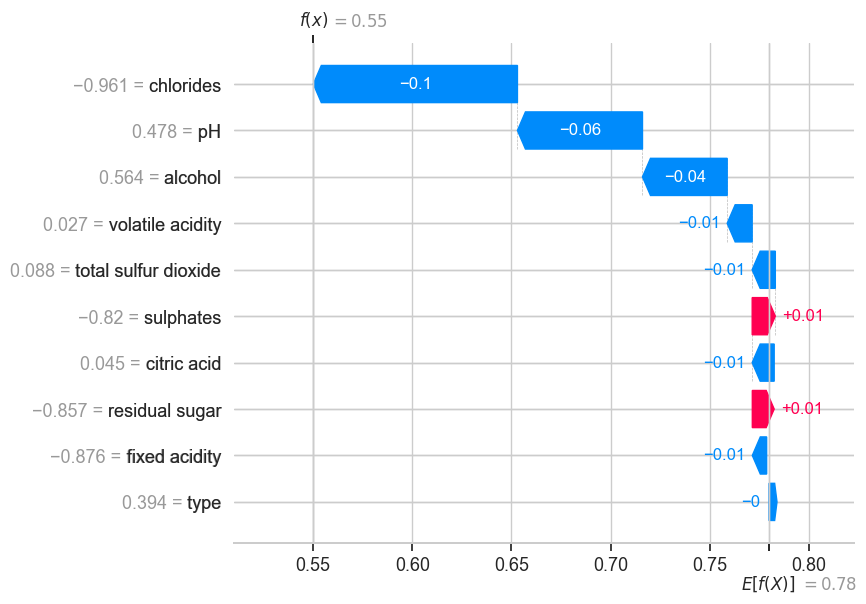

In [82]:
shap_values_test = explainer_shap(X_test_df)
shap.plots.waterfall(shap_values_test[i, :, 1])

Ce waterfall plot explique la prédiction pour **un seul vin**. Le modèle part d'une probabilité moyenne de 0.658, et la prédiction finale pour cet individu est **0.48**, donc en dessous de la moyenne. La variable la plus pénalisante est **alcohol** (-0.16), ce vin ayant un taux d'alcool faible (-0.89 standardisé), ce qui tire fortement la prédiction vers le bas. Les autres variables jouent des rôles plus modestes et s'annulent. Ce vin est globalement prédit comme étant de **qualité médiocre**, principalement à cause de son faible taux d'alcool.

## SHAP Scatter

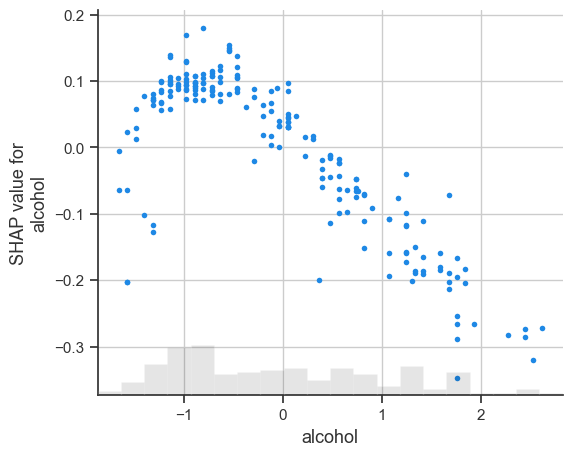

In [83]:
top1 = X_bis.columns[perm_imp.importances_mean.argmax()]
shap_200 = explainer_shap(X_test_df.iloc[:200])
shap.plots.scatter(shap_200[:, top1, 1])

Ce SHAP dependence plot confirme la relation vue dans le PDP : plus le taux d'alcool est élevé, plus sa valeur SHAP est positive — l'effet est **monotone et régulier**. On retrouve le seuil autour de 0 (valeur moyenne) où la contribution bascule de négative à positive.

# CONCLUSION

In [84]:
print("=" * 55)
print("RÉCAPITULATIF FINAL")
print("=" * 55)
print(df_results.to_string(index=False))
print()

meilleur = df_results.iloc[0]
print(f"Meilleur modèle : {meilleur['Modèle']}")
print(f"  Accuracy test : {meilleur['Accuracy']}")
print(f"  ROC-AUC       : {meilleur['ROC-AUC']}")
print()

print("Top 5 variables influentes (Permutation Importance) :")
top5 = X_bis.columns[perm_imp.importances_mean.argsort()[-5:][::-1]]
for rank, feat in enumerate(top5, 1):
    print(f"  {rank}. {feat}")

RÉCAPITULATIF FINAL
             Modèle  Accuracy  F1-macro  ROC-AUC
      Random Forest    0.8671    0.7718   0.8678
            SVM RBF    0.8497    0.7413   0.8022
Logistic Regression    0.7904    0.5554   0.6957

Meilleur modèle : Random Forest
  Accuracy test : 0.8671
  ROC-AUC       : 0.8678

Top 5 variables influentes (Permutation Importance) :
  1. alcohol
  2. chlorides
  3. residual sugar
  4. volatile acidity
  5. total sulfur dioxide
